In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned/cleaned_online_retail.csv")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2010-12-10 20:01:00')

Build RFM Table

In [5]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [6]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


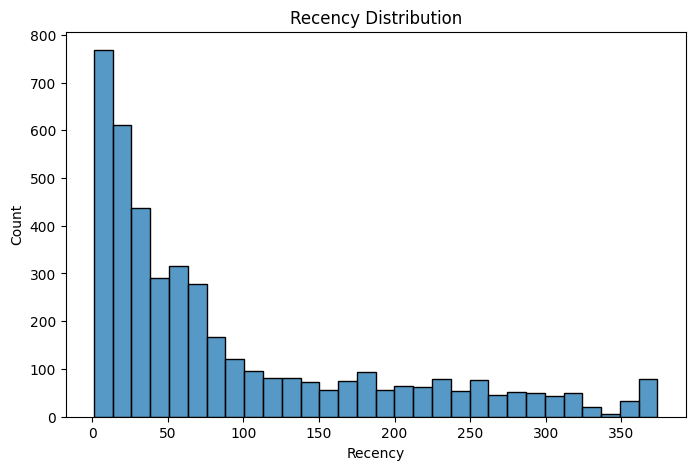

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Recency'],
    bins=30
)

plt.title("Recency Distribution")
plt.show()


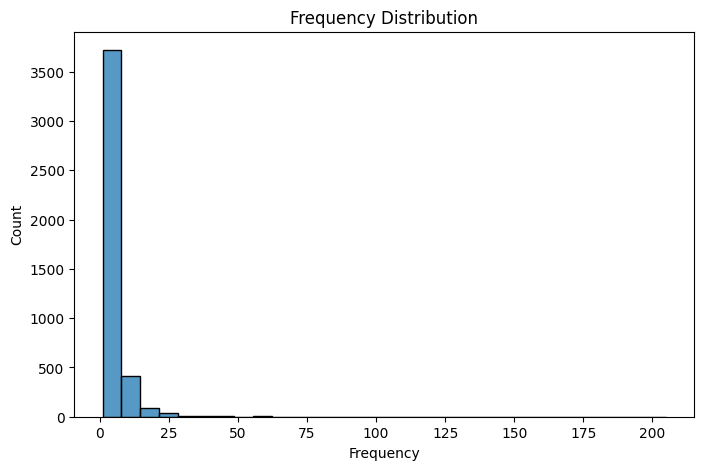

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Frequency'],
    bins=30
)

plt.title("Frequency Distribution")
plt.show()

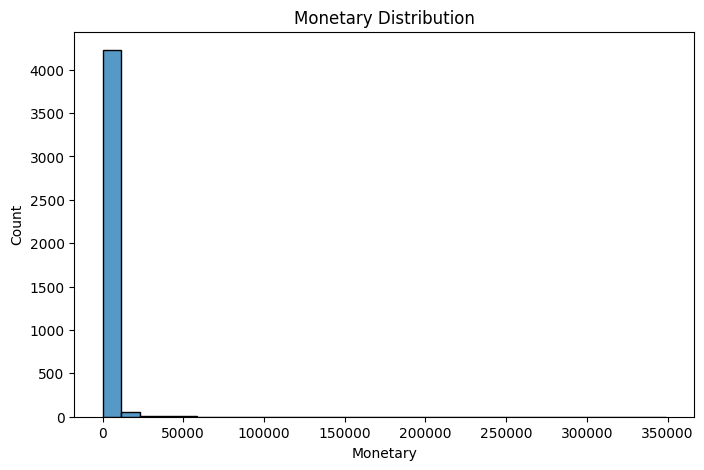

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Monetary'],
    bins=30
)

plt.title("Monetary Distribution")
plt.show()

RFM Scores

In [15]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,2,5,2,252
12347.0,3,2,1323.32,5,2,4,524
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,5,335
12351.0,11,1,300.93,5,1,2,512


Customer Segments

In [17]:
def segment_customer(row):

    if row['RFM_Score'] == '555':
        return "Champions"

    elif row['R_Score'] >= 4:
        return "Loyal Customers"

    elif row['R_Score'] <= 2:
        return "At Risk"

    else:
        return "Regular Customers"

In [20]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

rfm['Segment'].value_counts()

rfm[['R_Score','F_Score','M_Score']].head()

,R_Score,F_Score,M_Score
Customer ID,,,
12346.0,2,5,2
12347.0,5,2,4
12348.0,2,1,1
12349.0,3,3,5
12351.0,5,1,2


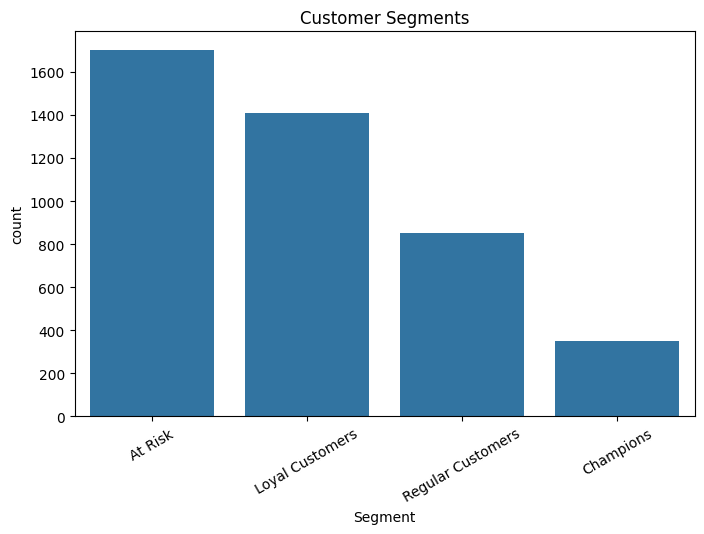

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.xticks(rotation=30)
plt.title("Customer Segments")
plt.show()

In [27]:
rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,187.68,2.19,848.63
Champions,6.50,18.67,11625.00
Loyal Customers,18.24,4.41,1563.31
Regular Customers,53.56,3.25,1284.27


K-Means Customer Segmentation

In [28]:
from sklearn.preprocessing import StandardScaler

rfm_ml = rfm[
    ['Recency','Frequency','Monetary']
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_ml)

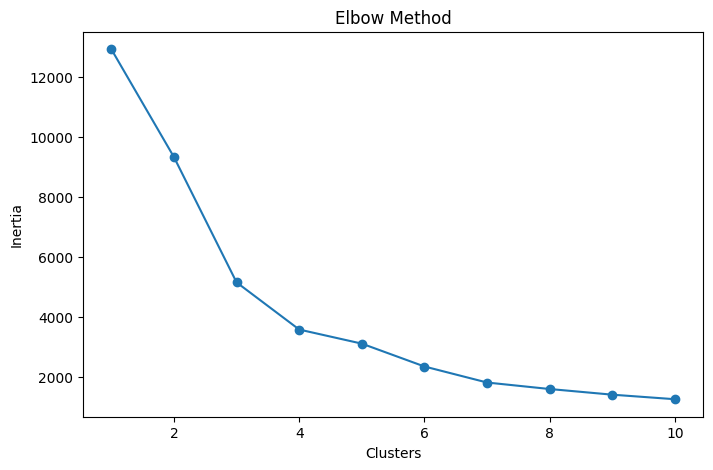

In [29]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [36]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.03,4.46,1710.65
1,242.98,1.66,593.54
2,5.60,113.60,215535.00
3,14.91,47.02,28896.42


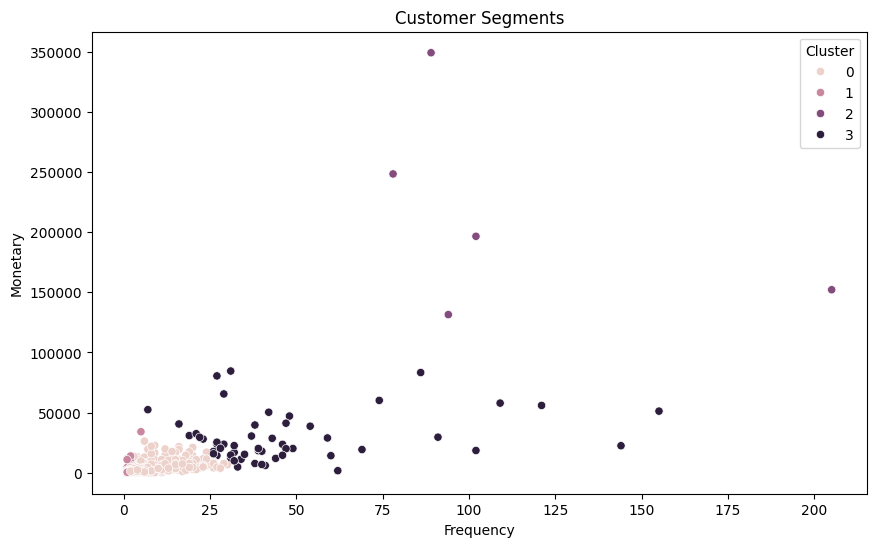

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm
)

plt.title("Customer Segments")
plt.show()

In [38]:
rfm.to_csv(
    "../data/processed/customer_segments.csv"
)